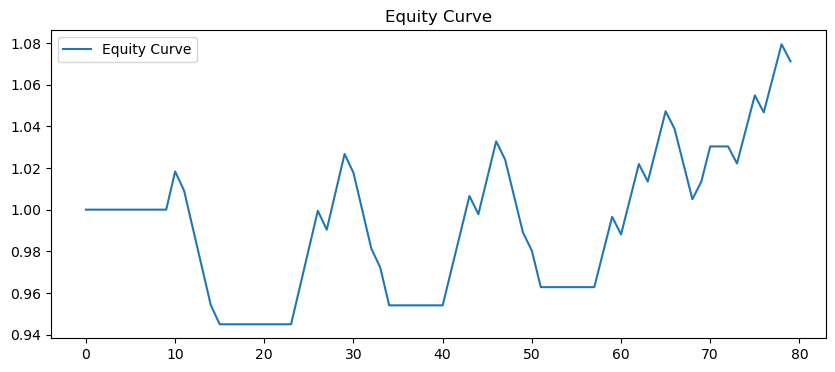

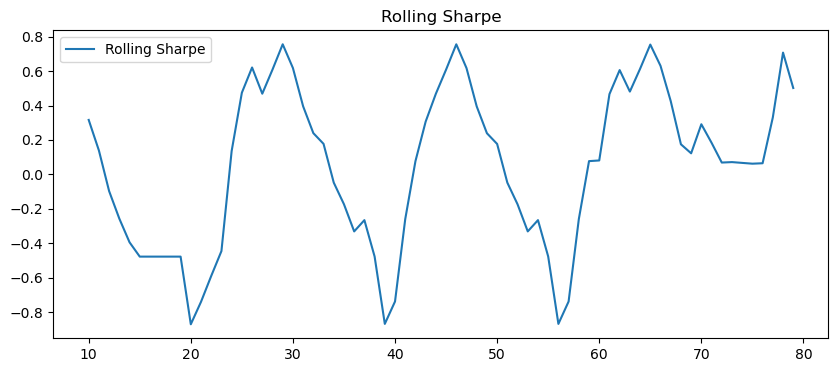

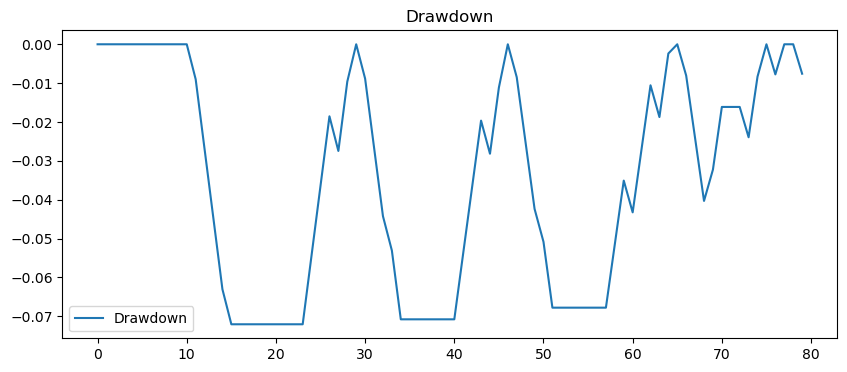

,Prices,Return,Fast_MA,Slow_MA,Signal,Strategy_Return,Equity_Curve,Running_Max,Drawdown,Rolling_Avg_Return,Rolling_Volatility,Rolling_Sharpe,Rolling_Max_Drawdown
0,100,NaN,NaN,NaN,0,0.000000,1.000000,1.000000,0.000000,NaN,NaN,NaN,NaN
1,102,0.020000,NaN,NaN,0,0.000000,1.000000,1.000000,0.000000,NaN,NaN,NaN,NaN
2,101,-0.009804,NaN,NaN,0,-0.000000,1.000000,1.000000,0.000000,NaN,NaN,NaN,NaN
3,103,0.019802,NaN,NaN,0,0.000000,1.000000,1.000000,0.000000,NaN,NaN,NaN,NaN
4,105,0.019417,102.2,NaN,0,0.000000,1.000000,1.000000,0.000000,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,129,0.015748,126.2,123.6,1,0.015748,1.054890,1.054890,0.000000,0.000803,0.012960,0.061946,-0.040323
76,128,-0.007752,127.0,124.1,1,-0.007752,1.046712,1.054890,-0.007752,0.000834,0.012936,0.064474,-0.040323
77,130,0.015625,127.8,125.0,1,0.015625,1.063067,1.063067,0.000000,0.004023,0.012161,0.330776,-0.040323
78,132,0.015385,129.2,126.3,1,0.015385,1.079422,1.079422,0.000000,0.007214,0.010197,0.707423,-0.032258


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


data = [100, 102, 101, 103, 105, 104, 106, 108, 107, 109,
111, 110, 108, 106, 104, 103, 101, 100, 98, 99,
101, 103, 102, 104, 106, 108, 110, 109, 111, 113,
112, 110, 108, 107, 105, 103, 104, 106, 108, 107,
109, 111, 113, 115, 114, 116, 118, 117, 115, 113,
112, 110, 108, 109, 111, 113, 112, 114, 116, 118,
117, 119, 121, 120, 122, 124, 123, 121, 119, 120,
122, 124, 126, 125, 127, 129, 128, 130, 132, 131]

fast_window = 5
slow_window = 10
rolling_window = 10

df = pd.DataFrame({'Prices' : data})
df['Return'] = df['Prices'].pct_change()
df['Fast_MA'] = df['Prices'].rolling(window=fast_window).mean()
df['Slow_MA'] = df['Prices'].rolling(window=slow_window).mean()
df['Signal'] = np.where(df['Fast_MA'] > df['Slow_MA'] , 1,0)
df['Strategy_Return'] = df['Return'] * df['Signal'].shift(1)
df['Strategy_Return'] = df['Strategy_Return'].fillna(0)
df['Equity_Curve'] = (1 + df['Strategy_Return']).cumprod()
df['Running_Max'] = df['Equity_Curve'].cummax()
df['Drawdown'] = (df['Equity_Curve'] - df['Running_Max'])/df['Running_Max']
df['Rolling_Avg_Return'] = df['Strategy_Return'].rolling(window = rolling_window).mean()
df['Rolling_Volatility'] = df['Strategy_Return'].rolling(window=rolling_window).std()
df['Rolling_Sharpe'] = df['Rolling_Avg_Return'] / df['Rolling_Volatility']
df['Rolling_Max_Drawdown'] = df['Drawdown'].rolling(window = rolling_window).min() 

plt.figure(figsize=(10,4))
plt.plot(df['Equity_Curve'],label = 'Equity Curve')
plt.legend()
plt.title('Equity Curve')
plt.show()

plt.figure(figsize=(10,4))
plt.plot(df['Rolling_Sharpe'],label = 'Rolling Sharpe')
plt.legend()
plt.title('Rolling Sharpe')
plt.show()

plt.figure(figsize =(10,4))
plt.plot(df['Drawdown'],label = 'Drawdown')
plt.legend()
plt.title('Drawdown')
plt.show()

df

## Observations

#1. The equity curve shows how the strategy compounded over time.
#2. Rolling average return helps identify whether recent performance was improving or weakening.
#3. Rolling volatility shows how unstable the strategy return was during different periods.
#4. Rolling Sharpe shows risk-adjusted performance over a moving 10-period window.
#5. Rolling max drawdown shows the worst recent loss from peak equity.
#6. Since the dataset is small, this analysis is useful for learning but not enough to trust the strategy in real markets.